# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

In [13]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = Path('../results/experiment_results.csv')
df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} rows from {RESULTS_CSV}")

# Filter to gpspp_800M runs only (hidden_dim=1536, gnn_depth=12)
# to ensure fair comparison across pre-training datasets.
df = df[df['hidden_dim'] == 1536].reset_index(drop=True)
print(f"After filtering to gpspp_800M (hidden_dim=1536): {len(df)} rows")

Loaded 424 rows from ../results/experiment_results.csv
After filtering to gpspp_800M (hidden_dim=1536): 197 rows


## 1. Overview: runs by model and task

In [14]:
print("Runs by model type:")
print(df['model'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model type:
model
pyg:gps    197

Runs by task:
task
multitask                         13
solubility_aqsoldb                12
caco2_wang                        12
pgp_broccatelli                    8
bioavailability_ma                 8
lipophilicity_astrazeneca          8
hia_hou                            8
bbb_martins                        8
ppbr_az                            8
cyp2d6_veith                       8
vdss_lombardo                      8
cyp2c9_veith                       8
cyp2c9_substrate_carbonmangels     8
cyp2d6_substrate_carbonmangels     8
cyp3a4_veith                       8
cyp3a4_substrate_carbonmangels     8
half_life_obach                    8
clearance_microsome_az             8
clearance_hepatocyte_az            8
ld50_zhu                           8
herg                               8
ames                               8
dili                               8

Finetuned: 162 / Scratch: 35


## 2. Extract primary metric per task

Each ADMET task has a primary metric. We extract the test metric column for each task.

In [15]:
# TDC ADMET primary metrics (ordered by category as in the TDC paper)
# https://tdcommons.ai/benchmark/admet_group/overview/

# Canonical task ordering: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity
ADMET_TASK_ORDER = [
    # Absorption
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    # Distribution
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    # Metabolism
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    # Excretion
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    # Toxicity
    'ld50_zhu', 'herg', 'ames', 'dili',
]

TASK_CATEGORY = {}
for t in ADMET_TASK_ORDER[:6]:   TASK_CATEGORY[t] = 'Absorption'
for t in ADMET_TASK_ORDER[6:9]:  TASK_CATEGORY[t] = 'Distribution'
for t in ADMET_TASK_ORDER[9:15]: TASK_CATEGORY[t] = 'Metabolism'
for t in ADMET_TASK_ORDER[15:18]: TASK_CATEGORY[t] = 'Excretion'
for t in ADMET_TASK_ORDER[18:]:  TASK_CATEGORY[t] = 'Toxicity'

TASK_METRICS = {
    'caco2_wang': ('mae', 'lower'),
    'hia_hou': ('auroc', 'higher'),
    'pgp_broccatelli': ('auroc', 'higher'),
    'bioavailability_ma': ('auroc', 'higher'),
    'lipophilicity_astrazeneca': ('mae', 'lower'),
    'solubility_aqsoldb': ('mae', 'lower'),
    'bbb_martins': ('auroc', 'higher'),
    'ppbr_az': ('mae', 'lower'),
    'vdss_lombardo': ('spearman', 'higher'),
    'cyp2d6_veith': ('auprc', 'higher'),
    'cyp3a4_veith': ('auprc', 'higher'),
    'cyp2c9_veith': ('auprc', 'higher'),
    'cyp2c9_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp2d6_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp3a4_substrate_carbonmangels': ('auroc', 'higher'),
    'half_life_obach': ('spearman', 'higher'),
    'clearance_hepatocyte_az': ('spearman', 'higher'),
    'clearance_microsome_az': ('spearman', 'higher'),
    'ld50_zhu': ('mae', 'lower'),
    'herg': ('auroc', 'higher'),
    'ames': ('auroc', 'higher'),
    'dili': ('auroc', 'higher'),
}

# TDC Leaderboard SOTA (rank #1) results: (mean, std, method_name)
# Source: https://tdcommons.ai/benchmark/admet_group/
TDC_SOTA = {
    'caco2_wang':                       (0.256, 0.006, 'CaliciBoost'),
    'hia_hou':                          (0.993, 0.005, 'MiniMol'),
    'pgp_broccatelli':                  (0.938, 0.002, 'MapLight + GNN'),
    'bioavailability_ma':               (0.942, 0.002, 'MiniMol'),
    'lipophilicity_astrazeneca':        (0.456, 0.008, 'MiniMol'),
    'solubility_aqsoldb':               (0.741, 0.013, 'MiniMol'),
    'bbb_martins':                      (0.924, 0.003, 'MiniMol'),
    'ppbr_az':                          (7.440, 0.024, 'Gradient Boost'),
    'vdss_lombardo':                    (0.713, 0.007, 'MapLight + GNN'),
    'cyp2d6_veith':                     (0.790, 0.001, 'MapLight + GNN'),
    'cyp3a4_veith':                     (0.916, 0.000, 'MapLight + GNN'),
    'cyp2c9_veith':                     (0.859, 0.001, 'MapLight + GNN'),
    'cyp2c9_substrate_carbonmangels':   (0.474, 0.025, 'MiniMol'),
    'cyp2d6_substrate_carbonmangels':   (0.736, 0.024, 'ContextPred'),
    'cyp3a4_substrate_carbonmangels':   (0.667, 0.019, 'CFA'),
    'half_life_obach':                  (0.576, 0.025, 'CFA'),
    'clearance_hepatocyte_az':          (0.536, 0.020, 'CFA'),
    'clearance_microsome_az':           (0.630, 0.010, 'MapLight + GNN'),
    'ld50_zhu':                         (0.552, 0.009, 'BaseBoosting'),
    'herg':                             (0.880, 0.002, 'MapLight + GNN'),
    'ames':                             (0.871, 0.002, 'ZairaChem'),
    'dili':                             (0.956, 0.006, 'MiniMol'),
}

def find_metric_column(df, task, metric_name):
    """Find the test metric column for a given task."""
    candidates = [c for c in df.columns if task in c.lower() and metric_name in c.lower() and 'test' in c.lower()]
    if candidates:
        return candidates[0]
    candidates = [c for c in df.columns if 'loss' in c.lower() and 'test' in c.lower()]
    return candidates[0] if candidates else None

def extract_primary_metric(row):
    """Extract the primary metric value for the task in this row."""
    task = row.get('task', '')
    if task not in TASK_METRICS:
        return np.nan
    metric_name, _ = TASK_METRICS[task]
    col = find_metric_column(df, task, metric_name)
    if col is None:
        return np.nan
    return row.get(col, np.nan)

df['primary_metric'] = df.apply(extract_primary_metric, axis=1)
df['metric_direction'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[1])
df['metric_name'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[0])
df['category'] = df['task'].map(TASK_CATEGORY)

print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

# Report rows that failed metric extraction
_failed = df[df['primary_metric'].isna()]
if len(_failed) > 0:
    print(f"\nFailed metric extraction ({len(_failed)} rows):")
    for task, count in _failed['task'].value_counts().items():
        if task not in TASK_METRICS:
            reason = "task not in TASK_METRICS (not an ADMET single-task)"
        else:
            metric_name, _ = TASK_METRICS[task]
            col = find_metric_column(df, task, metric_name)
            reason = f"metric column not found for '{metric_name}'" if col is None else "metric value is NaN"
        print(f"  - task='{task}' × {count} rows  ({reason})")

Tasks with extracted metrics: 184 / 197

Failed metric extraction (13 rows):
  - task='multitask' × 13 rows  (task not in TASK_METRICS (not an ADMET single-task))


## 3. Dataset type ablation

Compare downstream ADMET performance across pre-training datasets.

In [16]:
def parse_pretrain_dataset(pretrain_model_path):
    """Infer the pre-training dataset from the checkpoint path."""
    s = str(pretrain_model_path).lower()
    if s == 'scratch' or s == 'nan':
        return 'scratch'
    for name, patterns in [
        # Three-component patterns MUST come before two-component ones
        ('toymix_rxrx3_dti',   ['toymix_rxrx3_dti', 'toymix-rxrx3-dti', 'toymixrxrx3dti']),
        ('largemix_rxrx3_dti', ['largemix_rxrx3_dti', 'largemix-rxrx3-dti', 'largemixrxrx3dti']),
        # Two-component patterns
        ('largemix_rxrx3', ['largemix_rxrx3', 'largemixrxrx3', 'largemix-rxrx3']),
        ('largemix_dti',   ['largemix_dti', 'largemixdti', 'largemix-dti']),
        ('toymix_rxrx3',   ['toymix_rxrx3', 'toymixrxrx3', 'toymix-rxrx3']),
        ('toymix_dti',     ['toymix_dti', 'toymixdti', 'toymix-dti']),
        ('rxrx3_dti',      ['rxrx3_dti', 'rxrx3-dti', 'rxrx3dti', 'dti_rxrx3', 'dti-rxrx3', 'dtirxrx3']),
        # Single-component patterns
        ('largemix',       ['largemix', 'large-dataset']),
        ('toymix',         ['toymix', 'small-dataset']),
        ('rxrx3',          ['rxrx3']),
        ('dti',            ['/dti/', '/dti-']),
    ]:
        if any(p in s for p in patterns):
            return name
    return 'unknown'

def parse_data_fraction(row):
    """Extract data fraction from W&B tags, or from known checkpoint mapping."""
    tags = str(row.get('wandb_tags', ''))
    match = re.search(r'frac_(\d+\.?\d*)', tags)
    if match:
        return float(match.group(1))
    KNOWN_FRACS = {
        '2026-03-18_14-53-57': 0.5,  # toymix 50%
    }
    pt = str(row.get('pretrain_dataset', ''))
    for ts, frac in KNOWN_FRACS.items():
        if ts in pt:
            return frac
    return 1.0

def build_method_label(row):
    """Create a human-readable method label for the results table."""
    ft = row.get('is_finetuning', False)
    pt = row.get('pretrain_type', 'scratch')
    frac = row.get('data_fraction', 1.0)
    frac_str = f' {frac:.0%}' if frac < 1.0 else ''
    if not ft and pt == 'scratch':
        return 'Scratch'
    if ft:
        return f'FT ({pt}{frac_str})'
    return pt

def count_best_among_methods(task_method_pivot, methods, task_metrics):
    """Count how many tasks each method is the best performer (among the given methods)."""
    from collections import Counter
    wins = Counter()
    n_tasks = 0
    for task in task_method_pivot.index:
        if task not in task_metrics:
            continue
        direction = task_metrics[task][1]
        row = task_method_pivot.loc[task, [m for m in methods if m in task_method_pivot.columns]].dropna()
        if len(row) == 0:
            continue
        n_tasks += 1
        best = row.idxmin() if direction == 'lower' else row.idxmax()
        wins[best] += 1
    # Return ordered dict with all methods (0 wins if never best)
    return {m: (wins.get(m, 0), n_tasks) for m in methods if m in task_method_pivot.columns}

df['pretrain_type'] = df['pretrain_dataset'].apply(parse_pretrain_dataset)
df['primary_metric'] = pd.to_numeric(df['primary_metric'], errors='coerce')
df['data_fraction'] = df.apply(parse_data_fraction, axis=1)
df['method'] = df.apply(build_method_label, axis=1)

# Filter to ADMET tasks only, excluding unknown pretrain datasets
admet_df = df[df['task'].isin(TASK_METRICS.keys())].copy()
admet_df = admet_df[admet_df['pretrain_type'] != 'unknown']

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    pivot = admet_df.pivot_table(
        index='task', columns='method', values='primary_metric', aggfunc='mean'
    )

    row_order = [t for t in ADMET_TASK_ORDER if t in pivot.index]
    pivot = pivot.loc[row_order]

    method_order = ['Scratch'] + sorted([c for c in pivot.columns if c.startswith('FT')])
    method_order += [c for c in pivot.columns if c not in method_order]
    pivot = pivot[[c for c in method_order if c in pivot.columns]]

    row_labels = []
    for task in pivot.index:
        metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
        arrow = '\u2191' if direction == 'higher' else '\u2193'
        row_labels.append(f'{task}  ({metric_name} {arrow})')

    # Find best column per row (among our methods only, NOT SOTA)
    best_col_per_row = {}
    for task in pivot.index:
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        row_vals = pivot.loc[task].dropna()
        if len(row_vals) > 0:
            best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
            best_col_per_row[task] = best_col

    # Keep a numeric copy before inserting the SOTA string column
    numeric_pivot = pivot.copy()

    # Insert TDC SOTA column on the left (as formatted "mean ± std" strings)
    sota_col = []
    for task in pivot.index:
        if task in TDC_SOTA:
            mean, std, _ = TDC_SOTA[task]
            sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
        else:
            sota_col.append('')
    pivot.insert(0, 'TDC SOTA', sota_col)

    # Compute category boundaries dynamically from actual tasks in the pivot
    category_boundaries = set()
    prev_cat = None
    for i, task in enumerate(pivot.index):
        cat = TASK_CATEGORY.get(task)
        if prev_cat is not None and cat != prev_cat:
            category_boundaries.add(i)
        prev_cat = cat

    display_pivot = pivot.copy()
    display_pivot.index = row_labels

    def highlight_best(row):
        task = pivot.index[display_pivot.index.get_loc(row.name)]
        styles = [''] * len(row)
        if task in best_col_per_row:
            best_method = best_col_per_row[task]
            j = list(display_pivot.columns).index(best_method)
            styles[j] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'
        return styles

    def category_borders(row):
        idx = display_pivot.index.get_loc(row.name)
        if idx in category_boundaries:
            return ['border-top: 3px solid black'] * len(row)
        return [''] * len(row)

    def sota_style(col):
        if col.name == 'TDC SOTA':
            return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
        return [''] * len(col)

    styled = (
        display_pivot.style
        .format(precision=4, na_rep='', subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
        .apply(highlight_best, axis=1)
        .apply(category_borders, axis=1)
        .apply(sota_style, axis=0)
        .set_caption('ADMET Performance: Task x Method (TDC SOTA on left for reference)')
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
        ])
    )

    print("Primary metric per task x method:")
    print("(Ordered: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity)")
    print("Best per row: bold, blue, underlined (among our methods only)")
    display(styled)

    # Count tasks where each method is the best among all our methods
    best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
    print("\nTasks where each method is best (among our methods):")
    for method, (wins, total) in best_counts.items():
        print(f"  {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

Primary metric per task x method:
(Ordered: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity)
Best per row: bold, blue, underlined (among our methods only)


method,TDC SOTA,Scratch,FT (dti),FT (rxrx3),FT (rxrx3_dti),FT (toymix 50%),FT (toymix),FT (toymix_dti),FT (toymix_rxrx3)
caco2_wang (mae ↓),0.256 ± 0.006,0.5648,5.3263,1.2462,0.7230,0.5781,0.5372,0.5215,0.5438
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.4988,0.7267,0.8233,0.8333,0.7870,0.6066
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8214,0.5000,0.4373,0.8194,0.7704,0.8155,0.8656,0.8305
bioavailability_ma (auroc ↑),0.942 ± 0.002,0.5000,0.5000,0.5037,0.5786,0.6611,0.6275,0.5116,0.5449
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,0.9721,2.3666,0.9677,0.9647,0.9686,0.9724,0.8530,0.9782
solubility_aqsoldb (mae ↓),0.741 ± 0.013,1.0424,3.4085,1.8897,1.4641,1.5298,1.4957,1.2950,1.2084
bbb_martins (auroc ↑),0.924 ± 0.003,0.7324,0.5000,0.5569,0.7043,0.7237,0.7342,0.7825,0.7836
ppbr_az (mae ↓),7.440 ± 0.024,81.4208,88.6763,17.4642,15.7294,12.8629,13.3702,9.6743,9.6962
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.0541,0.2888,0.1293,0.2426,0.5812,0.3875
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.1488,0.4021,0.3480,0.2968,0.4884,0.4564



Tasks where each method is best (among our methods):
  Scratch: 3/22
  FT (dti): 0/22
  FT (rxrx3): 1/22
  FT (rxrx3_dti): 0/22
  FT (toymix 50%): 1/22
  FT (toymix): 2/22
  FT (toymix_dti): 12/22
  FT (toymix_rxrx3): 3/22


## 4. Aggregate comparison: scratch vs pre-trained

Bar chart comparing mean normalized performance.

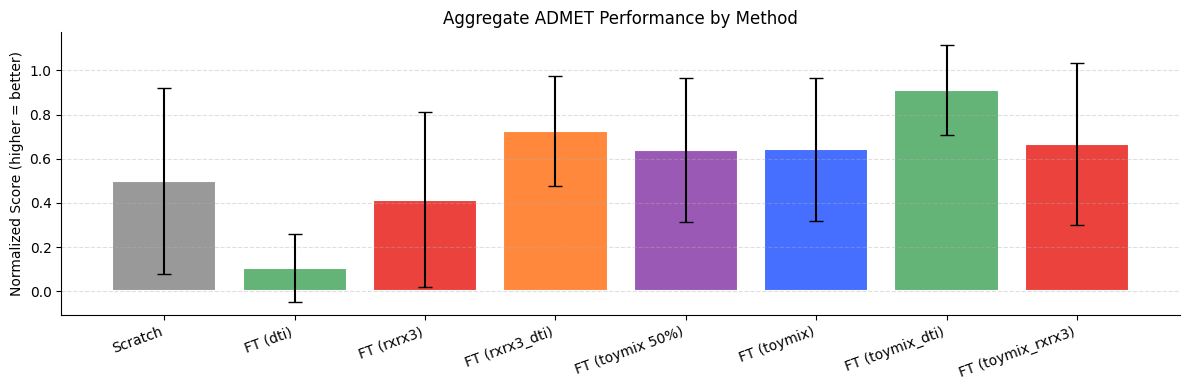

In [17]:
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    admet_df = admet_df.copy()
    
    # Normalize within each task: map metric to [0, 1] where 1 = best
    scores = []
    for task, group in admet_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    admet_df['normalized_score'] = pd.concat(scores).astype(float)
    
    agg = admet_df.groupby('method')['normalized_score'].agg(['mean', 'std', 'count'])
    # Order: Scratch first, then FT variants alphabetically
    order = ['Scratch'] + sorted([c for c in agg.index if c.startswith('FT')])
    order += [c for c in agg.index if c not in order]
    agg = agg.loc[[c for c in order if c in agg.index]]
    
    fig, ax = plt.subplots(figsize=(max(8, len(agg)*1.5), 4))
    palette = {'Scratch': '#999999'}
    ft_colors = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6']
    for i, m in enumerate(agg.index):
        if m not in palette:
            palette[m] = ft_colors[i % len(ft_colors)]
    colors = [palette.get(m, '#466eff') for m in agg.index]
    
    bars = ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'],
                  color=colors, capsize=5, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=20, ha='right')
    ax.set_ylabel('Normalized Score (higher = better)')
    ax.set_title('Aggregate ADMET Performance by Method')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)
    
    # for i, (bar, count) in enumerate(zip(bars, agg['count'])):
    #     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
    #             f'n={int(count)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No ADMET results to aggregate.")

## 5. Per-task comparison: SOTA vs selected methods

5×6 grid where each row is an ADMET category (Absorption, Distribution, Metabolism, Excretion, Toxicity).
TDC SOTA shown as a thick black horizontal line with ±std shading. Our methods shown as colored bars.

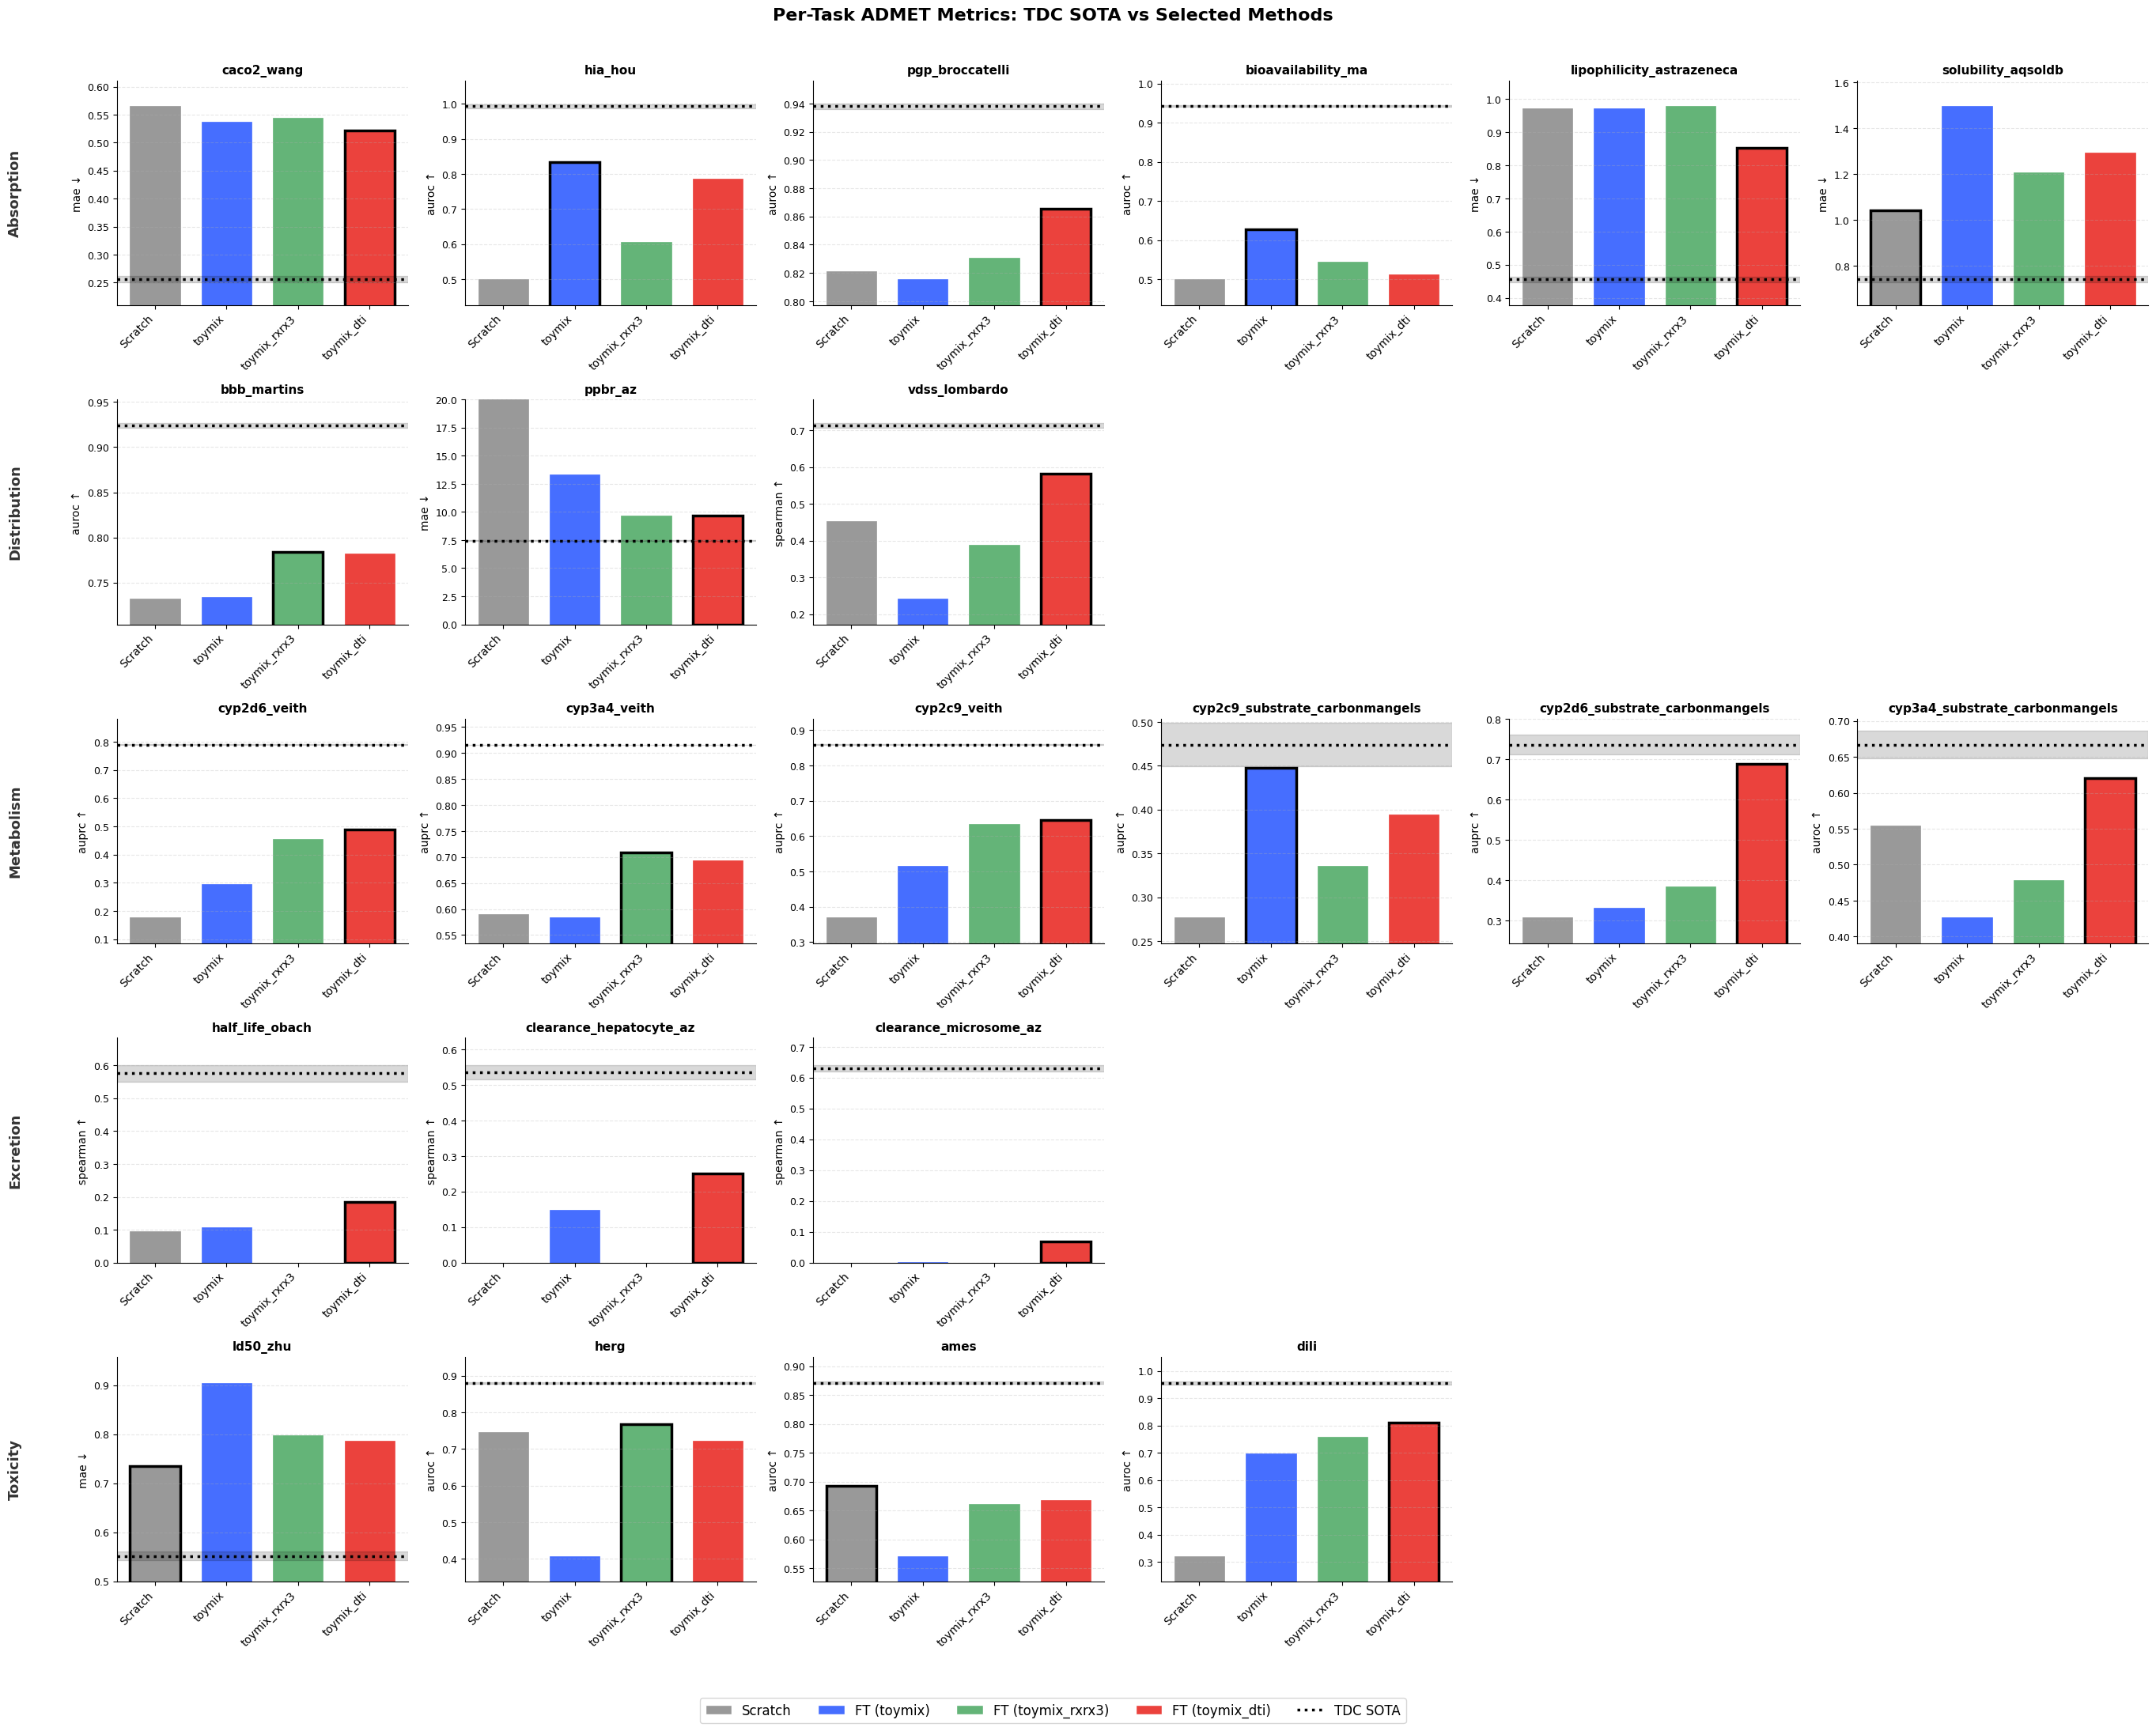


Methods shown (bars): ['Scratch', 'FT (toymix)', 'FT (toymix_rxrx3)', 'FT (toymix_dti)']
TDC SOTA: dotted black horizontal line with ±std shading
Best among our methods: highlighted with thick black border

Tasks where each method is best (among selected methods):
  Scratch: 3/22
  FT (toymix): 3/22
  FT (toymix_rxrx3): 3/22
  FT (toymix_dti): 13/22


In [18]:
# === Config: select which methods to compare alongside TDC SOTA ===
# Set to None to auto-include all available methods, or specify a list like:
SELECTED_METHODS = ['Scratch', 'FT (toymix)', 'FT (toymix_rxrx3)', 'FT (toymix_dti)']
# SELECTED_METHODS = None

# Per-task y-axis overrides: {task: (ymin, ymax)} — set either to None to auto-compute
TASK_YLIM_OVERRIDES = {
    'ppbr_az': (None, 20),
}

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    task_method_means = admet_df.groupby(['task', 'method'])['primary_metric'].mean()

    # Determine which methods to plot (bars only — SOTA is a horizontal line)
    all_available = sorted(admet_df['method'].unique())
    if SELECTED_METHODS is None:
        methods_to_plot = ['Scratch'] + [m for m in all_available if m != 'Scratch']
    else:
        methods_to_plot = [m for m in SELECTED_METHODS if m in all_available]

    short_labels = [
        m.replace('FT (', '').replace(')', '') if m.startswith('FT') else m
        for m in methods_to_plot
    ]
    n_bars = len(methods_to_plot)

    # Color palette (no SOTA color needed for bars)
    color_map = {'Scratch': '#999999'}
    ft_palette = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6',
                  '#17becf', '#bcbd22', '#e377c2']
    ft_idx = 0
    for m in methods_to_plot:
        if m not in color_map:
            color_map[m] = ft_palette[ft_idx % len(ft_palette)]
            ft_idx += 1
    colors = [color_map.get(m, '#466eff') for m in methods_to_plot]

    # Layout: 5 rows (one per ADMET category) × 6 cols
    CATEGORIES_ORDER = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
    CATEGORY_TASKS = {cat: [t for t in ADMET_TASK_ORDER if TASK_CATEGORY[t] == cat]
                      for cat in CATEGORIES_ORDER}

    fig, axes = plt.subplots(5, 6, figsize=(28, 22))
    x_pos = np.arange(n_bars)

    for row_idx, cat in enumerate(CATEGORIES_ORDER):
        tasks_in_cat = CATEGORY_TASKS[cat]
        for col_idx in range(6):
            ax = axes[row_idx, col_idx]

            # Hide unused subplots in this row
            if col_idx >= len(tasks_in_cat):
                ax.set_visible(False)
                continue

            task = tasks_in_cat[col_idx]
            metric_name, direction = TASK_METRICS[task]
            arrow = '\u2191' if direction == 'higher' else '\u2193'

            # Collect our method values
            vals = []
            for m in methods_to_plot:
                try:
                    vals.append(task_method_means.loc[(task, m)])
                except KeyError:
                    vals.append(np.nan)
            vals = np.array(vals, dtype=float)

            sota_mean = None
            if task in TDC_SOTA:
                sota_mean = TDC_SOTA[task][0]

            # Find best among our methods
            finite_mask = np.isfinite(vals)
            best_idx = None
            if any(finite_mask):
                if direction == 'lower':
                    best_idx = np.where(finite_mask, vals, np.inf).argmin()
                else:
                    best_idx = np.where(finite_mask, vals, -np.inf).argmax()

            # Plot bars for our methods
            for i, (v, c) in enumerate(zip(vals, colors)):
                if np.isfinite(v):
                    if i == best_idx:
                        ax.bar(i, v, color=c, edgecolor='black', linewidth=2.5, width=0.7)
                    else:
                        ax.bar(i, v, color=c, edgecolor=c, linewidth=0.5, width=0.7)

            # SOTA as dotted black horizontal line with ±std shading
            if sota_mean is not None:
                _, sota_std, sota_method = TDC_SOTA[task]
                ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
                ax.axhspan(sota_mean - sota_std, sota_mean + sota_std,
                           alpha=0.15, color='black', zorder=1)

            # Adjust y-axis limits to zoom into the data range
            all_finite = vals[np.isfinite(vals)].tolist()
            if sota_mean is not None:
                all_finite.append(sota_mean)
            if len(all_finite) >= 1:
                vmin, vmax = min(all_finite), max(all_finite)
                span = vmax - vmin if vmax > vmin else vmax * 0.1
                padding = span * 0.15
                ylo = max(0, vmin - padding)
                yhi = vmax + padding
                # Apply per-task overrides
                if task in TASK_YLIM_OVERRIDES:
                    override_lo, override_hi = TASK_YLIM_OVERRIDES[task]
                    if override_lo is not None:
                        ylo = override_lo
                    if override_hi is not None:
                        yhi = override_hi
                ax.set_ylim(ylo, yhi)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=10)
            ax.set_title(f'{task}', fontsize=11, fontweight='bold')
            ax.set_ylabel(f'{metric_name} {arrow}', fontsize=10)
            ax.tick_params(axis='y', labelsize=9)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

            # Category label on leftmost subplot of each row
            if col_idx == 0:
                ax.annotate(cat, xy=(-0.35, 0.5), xycoords='axes fraction',
                            fontsize=13, fontweight='bold', color='#333',
                            ha='center', va='center', rotation=90)

    # Legend at bottom: colored patches for methods + dotted black line for SOTA
    legend_handles = [Patch(facecolor=c, edgecolor='white', label=m)
                      for c, m in zip(colors, methods_to_plot)]
    legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5,
                                 linestyle=':', label='TDC SOTA'))
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=min(len(legend_handles), 8), fontsize=12,
               bbox_to_anchor=(0.5, -0.01), frameon=True)

    fig.suptitle('Per-Task ADMET Metrics: TDC SOTA vs Selected Methods',
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    plt.show()

    print(f"\nMethods shown (bars): {methods_to_plot}")
    print("TDC SOTA: dotted black horizontal line with \u00b1std shading")
    print("Best among our methods: highlighted with thick black border")

    # Count tasks where each selected method is best among the selected set
    grid_pivot = task_method_means.unstack(fill_value=np.nan)
    grid_pivot = grid_pivot.loc[[t for t in ADMET_TASK_ORDER if t in grid_pivot.index]]
    best_counts = count_best_among_methods(grid_pivot, methods_to_plot, TASK_METRICS)
    print("\nTasks where each method is best (among selected methods):")
    for method, (wins, total) in best_counts.items():
        print(f"  {method}: {wins}/{total}")
else:
    print("No ADMET results to plot.")